Using cache found in /Users/diegobernalm1/.cache/torch/hub/facebookresearch_detr_main
/opt/anaconda3/envs/p3.9/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/p3.9/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


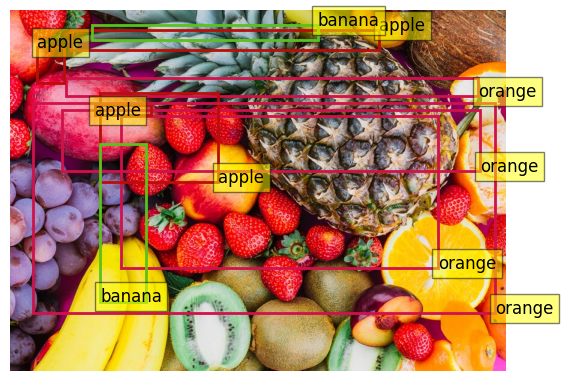

In [1]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# Usar GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Etiquetas COCO (91 clases)
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A',
    'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant',
    'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

colors = np.random.rand(len(CLASSES), 3)


def load_image(path_or_url):
    if path_or_url.startswith("http"):
        from io import BytesIO
        import requests
        image = Image.open(BytesIO(requests.get(path_or_url).content)).convert("RGB")
    else:
        image = Image.open(path_or_url).convert("RGB")
    return image


def transform_image(image):
    transform = T.Compose([
        T.Resize(800),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0).to(device)


def rescale_bboxes(bboxes, size):
    img_w, img_h = size
    b = bboxes.clone()
    b[:, [0, 2]] *= img_w
    b[:, [1, 3]] *= img_h
    return b


def detect_and_plot(image_path, threshold=0.8):
    image = load_image(image_path)
    img_tensor = transform_image(image)

    # Cargar modelo
    model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)
    model.to(device).eval()

    with torch.no_grad():
        outputs = model(img_tensor)

    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > threshold

    if keep.sum() == 0:
        print("⚠️ No se detectaron objetos con confianza > ", threshold)
        return

    labels = probas[keep].argmax(-1)
    boxes = rescale_bboxes(outputs['pred_boxes'][0, keep], image.size)

    plt.imshow(image)
    ax = plt.gca()

    for box, label in zip(boxes, labels):
        color = colors[label]
        x0, y0, x1, y1 = box.tolist()
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                   fill=False, color=color, linewidth=2))
        ax.text(x0, y0, CLASSES[label], fontsize=12,
                bbox=dict(facecolor='yellow', alpha=0.5))

    plt.axis('off')
    plt.show()


# 🔍 Ejecutar detección
detect_and_plot("uno/f5.jpg")  # o una URL
